In [1]:
# importing required libraries
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Importing the cleaned dataset

In [3]:
dfT1DData = pd.read_excel("C:/Users/bhara/Documents/Python Data Analysis/Type 1 Diabetes Dataset/Type1_Diabetes_Analysis.xlsx")

#### Can we predict next-day average glucose levels based on today’s insulin (basal + bolus), carb intake, and activity (steps, calories burned, heart rate)?

- **Goal:** Build a regression model that forecasts glucose control for tomorrow from lifestyle and insulin data today.

- **Clinical Insight:** Helps anticipate risk of hyper/hypoglycemia and optimize daily therapy.


LinearRegression performance:
  RMSE_train: 27.648
  MAE_train: 22.639
  R2_train: 0.365
  RMSE_test: 37.379
  MAE_test: 29.523
  R2_test: 0.254

RandomForest performance:
  RMSE_train: 12.572
  MAE_train: 9.940
  R2_train: 0.869
  RMSE_test: 34.486
  MAE_test: 26.035
  R2_test: 0.365


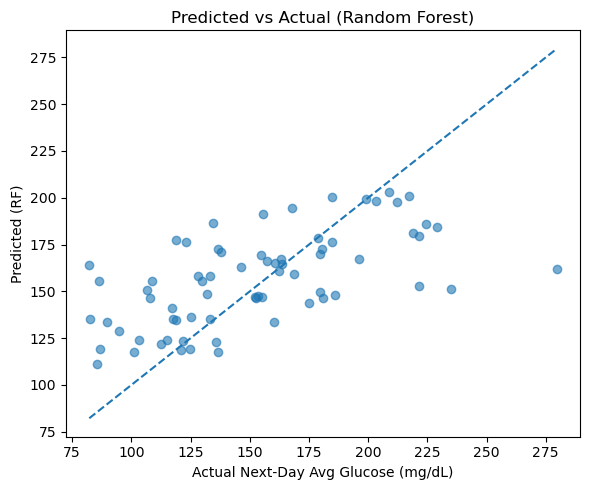

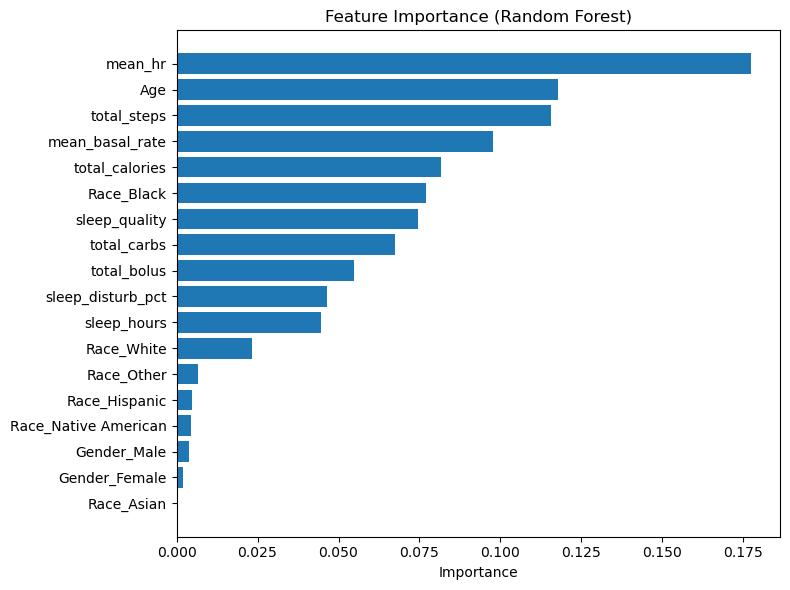

,feature,importance
5,mean_hr,0.177463
9,Age,0.117911
3,total_steps,0.115697
1,mean_basal_rate,0.097807
4,total_calories,0.081504
13,Race_Black,0.077046
7,sleep_quality,0.074524
2,total_carbs,0.067463
0,total_bolus,0.054928
8,sleep_disturb_pct,0.046317


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings("ignore")

# ---------- Preparing daily features ----------
df = dfT1DData.copy()

# Parse date from 'date' (preferred); if missing/empty, fall back to date_time
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.date
else:
    df["date_time"] = pd.to_datetime(df["date_time"], errors="coerce")
    df["date"] = df["date_time"].dt.date

# Ensuring numeric types where needed
num_cols_force = [
    "glucose", "calories_burned", "heart_rate", "steps",
    "basal_rate", "bolus_volume_delivered", "carb_input_g",
    "Average Sleep Duration (hrs)", "Sleep Quality (1-10)",
    "% with Sleep Disturbances", "Age"
]
for c in num_cols_force:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop rows without key fields
df = df.dropna(subset=["patient_id", "date", "glucose"])

# Daily aggregation per patient (today's features)
daily = (
    df.groupby(["patient_id", "date"], as_index=False)
      .agg(
          avg_glucose=("glucose", "mean"),                    # today's avg glucose (used only to build target via shift)
          total_bolus=("bolus_volume_delivered", "sum"),
          mean_basal_rate=("basal_rate", "mean"),
          total_carbs=("carb_input_g", "sum"),
          total_steps=("steps", "sum"),
          total_calories=("calories_burned", "sum"),
          mean_hr=("heart_rate", "mean"),
          sleep_hours=("Average Sleep Duration (hrs)", "mean"),
          sleep_quality=("Sleep Quality (1-10)", "mean"),
          sleep_disturb_pct=("% with Sleep Disturbances", "mean")
      )
)

# Attaching demographics (single value per patient)
demo = (
    df.groupby("patient_id", as_index=False)
      .agg(
          Age=("Age", "first"),
          Gender=("Gender", "first"),
          Race=("Race", "first")
      )
)

daily = daily.merge(demo, on="patient_id", how="left")

# ---------- Building next-day target per patient ----------
daily = daily.sort_values(["patient_id", "date"])

# Next-day average glucose (per patient)
daily["target_nextday_avg_gluc"] = (
    daily.groupby("patient_id")["avg_glucose"].shift(-1)
)

# Remove rows where next day is not available
daily_model = daily.dropna(subset=["target_nextday_avg_gluc"]).reset_index(drop=True)

# ---------- 3) Train/test split (time-aware per patient) ----------
# Mark the last 20% days per patient as test
def mark_last_20_percent(group):
    n = len(group)
    cutoff = int(np.floor(0.8 * n))
    # first 80% -> train (False), last 20% -> test (True)
    mask = np.array([False]*cutoff + [True]*(n-cutoff))
    group = group.copy()
    group["is_test"] = mask
    return group

daily_model = (
    daily_model.groupby("patient_id", group_keys=False)
               .apply(mark_last_20_percent)
)

train_df = daily_model[daily_model["is_test"] == False]
test_df  = daily_model[daily_model["is_test"] == True]

# ---------- Features & target ----------
feature_cols_num = [
    "total_bolus",
    "mean_basal_rate",
    "total_carbs",
    "total_steps",
    "total_calories",
    "mean_hr",
    "sleep_hours",
    "sleep_quality",
    "sleep_disturb_pct",
    "Age"
]
feature_cols_cat = []
if "Gender" in daily_model.columns: feature_cols_cat.append("Gender")
if "Race"   in daily_model.columns: feature_cols_cat.append("Race")

X_train = train_df[feature_cols_num + feature_cols_cat].copy()
X_test  = test_df[feature_cols_num + feature_cols_cat].copy()
y_train = train_df["target_nextday_avg_gluc"].copy()
y_test  = test_df["target_nextday_avg_gluc"].copy()

# ---------- 5) Pipelines ----------
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), feature_cols_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_cat)
    ],
    remainder="drop"
)

linreg = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LinearRegression())
])

rf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1,
        max_depth=None,
        min_samples_leaf=2
    ))
])

# ---------- 6) Train ----------
linreg.fit(X_train, y_train)
rf.fit(X_train, y_train)

# ---------- 7) Evaluate ----------
def eval_and_print(name, model, X_tr, y_tr, X_te, y_te):
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)
    metrics = {
        "RMSE_train": mean_squared_error(y_tr, pred_tr, squared=False),
        "MAE_train":  mean_absolute_error(y_tr, pred_tr),
        "R2_train":   r2_score(y_tr, pred_tr),
        "RMSE_test":  mean_squared_error(y_te, pred_te, squared=False),
        "MAE_test":   mean_absolute_error(y_te, pred_te),
        "R2_test":    r2_score(y_te, pred_te)
    }
    print(f"\n{name} performance:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.3f}")
    return pred_te

pred_lin = eval_and_print("LinearRegression", linreg, X_train, y_train, X_test, y_test)
pred_rf  = eval_and_print("RandomForest",     rf,    X_train, y_train, X_test, y_test)

# ---------- 8) Plots ----------
# Predicted vs Actual (test set)
plt.figure(figsize=(6,5))
plt.scatter(y_test, pred_rf, alpha=0.6)
min_val, max_val = min(y_test.min(), pred_rf.min()), max(y_test.max(), pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")  # 45° line
plt.xlabel("Actual Next-Day Avg Glucose (mg/dL)")
plt.ylabel("Predicted (RF)")
plt.title("Predicted vs Actual (Random Forest)")
plt.tight_layout()
plt.show()

# Feature importances (RF)
# Extract feature names after preprocessing
cat_feature_names = []
if feature_cols_cat:
    ohe = rf.named_steps["prep"].named_transformers_["cat"]
    cat_feature_names = list(ohe.get_feature_names_out(feature_cols_cat))
feature_names = feature_cols_num + cat_feature_names

rf_model = rf.named_steps["model"]
importances = rf_model.feature_importances_
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,6))
plt.barh(imp_df["feature"], imp_df["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

imp_df.head(15)

#### Can sleep quality and duration predict the risk of hypoglycemia (<70) or hyperglycemia (>180) on the following day?

- **Goal:** Train a classification model (e.g., logistic regression, random forest) to predict whether a patient will have extreme glucose events tomorrow based on prior night’s sleep.

- **Clinical Insight:** Links sleep hygiene with glycemic risk.

=== Next-Day HYPO (<70) ===

LogisticRegression
  Accuracy: 0.548
  Precision: 0.500
  Recall: 0.515
  F1: 0.507
  ROC_AUC: 0.547

RandomForest
  Accuracy: 0.466
  Precision: 0.456
  Recall: 0.939
  F1: 0.614
  ROC_AUC: 0.542

=== Next-Day HYPER (>180) ===

LogisticRegression
  Accuracy: 0.548
  Precision: 0.651
  Recall: 0.609
  F1: 0.629
  ROC_AUC: 0.504

RandomForest
  Accuracy: 0.630
  Precision: 0.630
  Recall: 1.000
  F1: 0.773
  ROC_AUC: 0.529


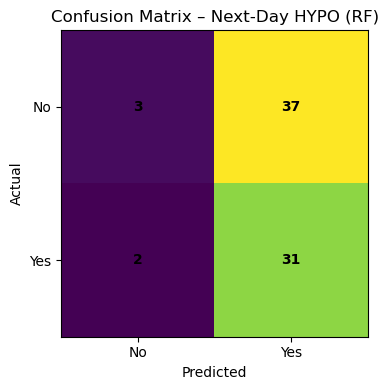

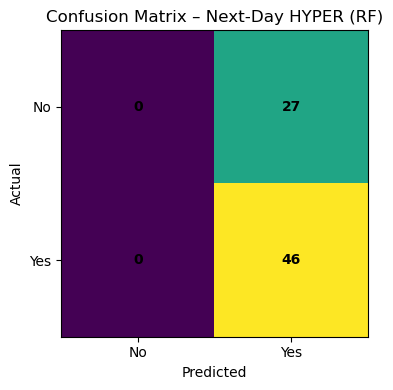

In [7]:
# ============================================
# Predict next-day hypo (<70) / hyper (>180)
# from prior night's sleep duration & quality
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix
)
import warnings
warnings.filterwarnings("ignore")

# ---------- 1) Preparing daily aggregates ----------
df = dfT1DData.copy()

# Parse date (prefer 'date' if present)
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.date
else:
    df["date_time"] = pd.to_datetime(df["date_time"], errors="coerce")
    df["date"] = df["date_time"].dt.date

# Numeric enforcement for needed columns
num_cols = [
    "glucose","basal_rate","bolus_volume_delivered","carb_input_g",
    "steps","calories_burned","heart_rate",
    "Average Sleep Duration (hrs)","Sleep Quality (1-10)","% with Sleep Disturbances","Age"
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop rows missing essentials
df = df.dropna(subset=["patient_id","date","glucose"])

# Daily stats per patient
daily = (
    df.groupby(["patient_id","date"], as_index=False)
      .agg(
          min_glucose=("glucose","min"),
          max_glucose=("glucose","max"),
          avg_glucose=("glucose","mean"),
          sleep_hours=("Average Sleep Duration (hrs)","mean"),
          sleep_quality=("Sleep Quality (1-10)","mean"),
          sleep_disturb_pct=("% with Sleep Disturbances","mean")
      )
)

# Demographics (optional covariates later if you want)
demo = (
    df.groupby("patient_id", as_index=False)
      .agg(
          Age=("Age","first"),
          Gender=("Gender","first"),
          Race=("Race","first")
      )
)
daily = daily.merge(demo, on="patient_id", how="left")

# ---------- 2) Building next-day targets ----------
# Sort within patient by date
daily = daily.sort_values(["patient_id","date"])

# Next-day outcomes (1 if ANY reading tomorrow meets criterion)
daily["nextday_hypo"]  = daily.groupby("patient_id")["min_glucose"].shift(-1).lt(70).astype("float")
daily["nextday_hyper"] = daily.groupby("patient_id")["max_glucose"].shift(-1).gt(180).astype("float")

# Keep rows where next day exists
daily = daily.dropna(subset=["nextday_hypo","nextday_hyper"]).reset_index(drop=True)

# ---------- 3) Train/Test split (time-aware per patient) ----------
def mark_last_20_percent(g):
    n = len(g)
    cut = int(np.floor(0.8*n))
    mask = np.array([False]*cut + [True]*(n-cut))
    g = g.copy()
    g["is_test"] = mask
    return g

daily = daily.groupby("patient_id", group_keys=False).apply(mark_last_20_percent)

# Features (sleep-only, as requested)
feature_cols_num = ["sleep_hours","sleep_quality"]
# (Optional extras to improve model: add "sleep_disturb_pct","Age")

# Targets
y_hypo  = daily["nextday_hypo"].astype(int)
y_hyper = daily["nextday_hyper"].astype(int)

X = daily[feature_cols_num].copy()

# Split
X_train = X[daily["is_test"] == False]
X_test  = X[daily["is_test"] == True]
y_hypo_train  = y_hypo[daily["is_test"] == False]
y_hypo_test   = y_hypo[daily["is_test"] == True]
y_hyper_train = y_hyper[daily["is_test"] == False]
y_hyper_test  = y_hyper[daily["is_test"] == True]

# ---------- 4) Pipelines ----------
prep = ColumnTransformer(
    transformers=[("num", StandardScaler(), feature_cols_num)],
    remainder="drop"
)

logreg = Pipeline(steps=[
    ("prep", prep),
    ("model", LogisticRegression(max_iter=500, class_weight="balanced"))
])

rf = Pipeline(steps=[
    ("prep", prep),
    ("model", RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        min_samples_leaf=2,
        n_jobs=-1
    ))
])

def fit_eval_binary(name, pipe, Xtr, ytr, Xte, yte):
    pipe.fit(Xtr, ytr)
    p = pipe.predict(Xte)
    pprob = pipe.predict_proba(Xte)[:,1]
    metrics = {
        "Accuracy": accuracy_score(yte, p),
        "Precision": precision_score(yte, p, zero_division=0),
        "Recall": recall_score(yte, p, zero_division=0),
        "F1": f1_score(yte, p, zero_division=0),
        "ROC_AUC": roc_auc_score(yte, pprob) if len(np.unique(yte))>1 else np.nan
    }
    print(f"\n{name}")
    for k,v in metrics.items():
        print(f"  {k}: {v:.3f}")
    return pipe, p, pprob

# ---------- 5) Train & evaluate: HYPO ----------
print("=== Next-Day HYPO (<70) ===")
lr_hypo,  pred_hypo_lr,  proba_hypo_lr  = fit_eval_binary("LogisticRegression", logreg, X_train, y_hypo_train, X_test, y_hypo_test)
rf_hypo,  pred_hypo_rf,  proba_hypo_rf  = fit_eval_binary("RandomForest",      rf,     X_train, y_hypo_train, X_test, y_hypo_test)

# ---------- 6) Train & evaluate: HYPER ----------
print("\n=== Next-Day HYPER (>180) ===")
lr_hyper, pred_hyper_lr, proba_hyper_lr = fit_eval_binary("LogisticRegression", logreg, X_train, y_hyper_train, X_test, y_hyper_test)
rf_hyper, pred_hyper_rf, proba_hyper_rf = fit_eval_binary("RandomForest",      rf,     X_train, y_hyper_train, X_test, y_hyper_test)

# ---------- 7) Confusion matrices (with counts on the chart) ----------
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    fig, ax = plt.subplots(figsize=(4,4))
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_xticklabels(["No", "Yes"]); ax.set_yticklabels(["No", "Yes"])
    # value labels
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_cm(y_hypo_test,  pred_hypo_rf,  "Confusion Matrix – Next-Day HYPO (RF)")
plot_cm(y_hyper_test, pred_hyper_rf, "Confusion Matrix – Next-Day HYPER (RF)")



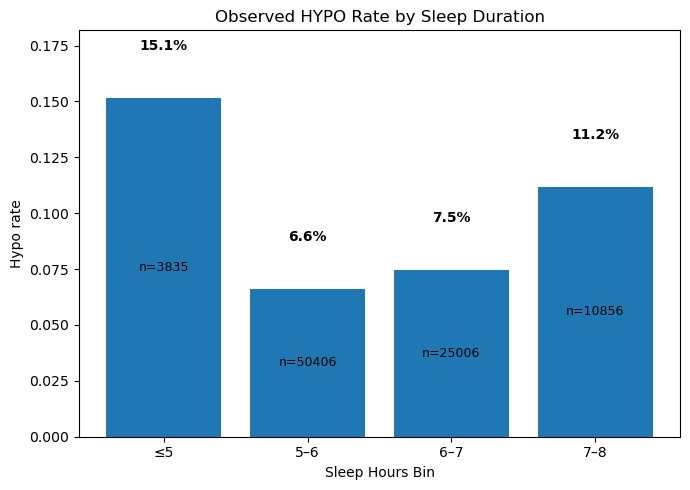

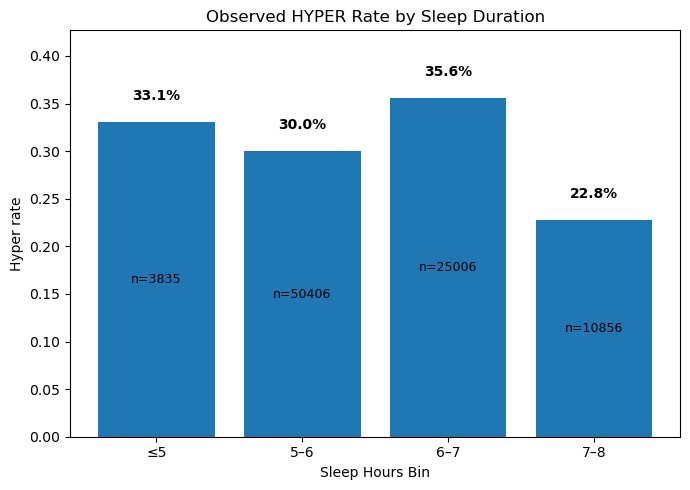

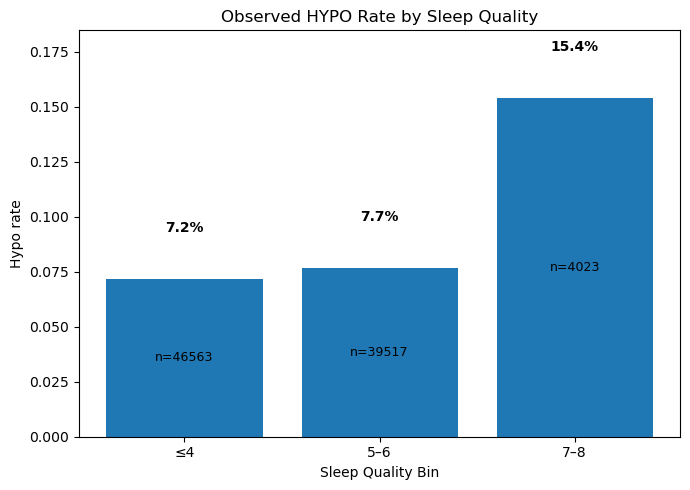

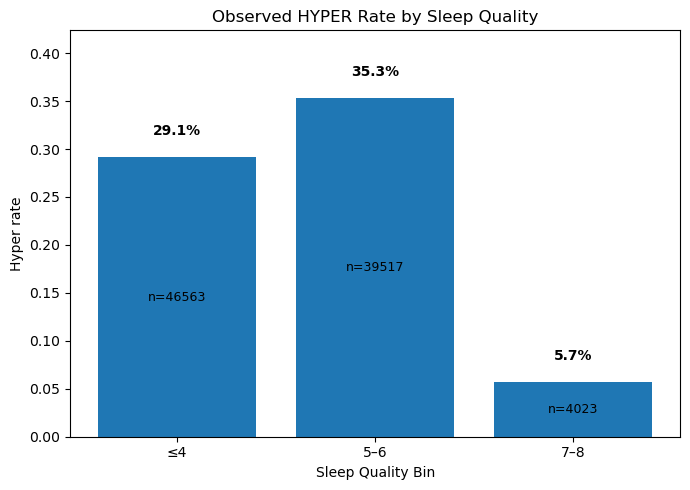

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Start from your main dataframe
eval_df = dfT1DData.copy()

# Make sure required columns exist and are numeric
eval_df["sleep_hours"] = pd.to_numeric(eval_df["Average Sleep Duration (hrs)"], errors="coerce")
eval_df["sleep_quality"] = pd.to_numeric(eval_df["Sleep Quality (1-10)"], errors="coerce")

# Drop rows where key fields are missing
eval_df = eval_df.dropna(subset=["sleep_hours", "sleep_quality"])

# If your hypo/hyper flags aren’t already created, define them
eval_df["hypo"] = (eval_df["glucose"] < 70).astype(int)
eval_df["hyper"] = (eval_df["glucose"] > 180).astype(int)

# ---------- Binning helpers ----------
def bin_sleep_hours(s):
    bins   = [0, 5, 6, 7, 8, 24]
    labels = ["≤5","5–6","6–7","7–8",">8"]
    return pd.cut(s, bins=bins, labels=labels, include_lowest=True, right=True, ordered=True)

def bin_sleep_quality(s):
    bins   = [0, 4, 6, 8, 10]
    labels = ["≤4","5–6","7–8","9–10"]
    return pd.cut(s, bins=bins, labels=labels, include_lowest=True, right=True, ordered=True)

eval_df["sleep_hours_bin"]   = bin_sleep_hours(eval_df["sleep_hours"])
eval_df["sleep_quality_bin"] = bin_sleep_quality(eval_df["sleep_quality"])

# ---------- Plot function ----------
def rate_chart(df, group_col, target_col, title, ylabel):
    grp = (
        df.groupby(group_col, observed=True)
          .agg(n=("patient_id", "size"), rate=(target_col, "mean"))
          .reset_index()
    )
    grp = grp[(grp["n"] > 0) & (grp["rate"].notna())]

    if grp.empty:
        print(f"[{title}] No data to plot after cleaning.")
        return grp

    plt.figure(figsize=(7,5))
    bars = plt.bar(grp[group_col].astype(str), grp["rate"])
    plt.title(title)
    plt.xlabel(group_col.replace("_"," ").title())
    plt.ylabel(ylabel)

    for i,(r,n) in enumerate(zip(grp["rate"], grp["n"])):
        plt.text(i, r+0.02, f"{r*100:.1f}%", ha="center", va="bottom", fontweight="bold")
        plt.text(i, r/2, f"n={n}", ha="center", va="center", fontsize=9)

    plt.ylim(0, grp["rate"].max()*1.2)
    plt.tight_layout()
    plt.show()
    return grp

# ---------- Run charts ----------
grp_hypo_hours  = rate_chart(eval_df, "sleep_hours_bin", "hypo",  "Observed HYPO Rate by Sleep Duration",  "Hypo rate")
grp_hyper_hours = rate_chart(eval_df, "sleep_hours_bin", "hyper", "Observed HYPER Rate by Sleep Duration", "Hyper rate")
grp_hypo_qual   = rate_chart(eval_df, "sleep_quality_bin", "hypo","Observed HYPO Rate by Sleep Quality",   "Hypo rate")
grp_hyper_qual  = rate_chart(eval_df, "sleep_quality_bin", "hyper","Observed HYPER Rate by Sleep Quality", "Hyper rate")

#### Can daily activity patterns (steps, heart rate, calories burned) predict whether glucose will remain in the target range (70–180) for most of the day?
- **Goal:** Use classification models to predict “Time in Range (TIR)” based on fitness tracker metrics.

- **Clinical Insight:** Quantifies how lifestyle and exercise affect glucose control.



Logistic Regression Results:
Accuracy : 0.5522388059701493
Precision: 0.43902439024390244
Recall   : 0.72
F1 Score : 0.5454545454545454
ROC AUC  : 0.6161904761904762


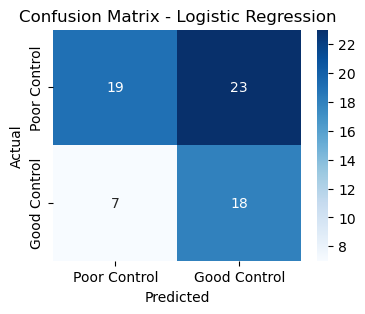


Random Forest Results:
Accuracy : 0.7164179104477612
Precision: 0.6666666666666666
Recall   : 0.48
F1 Score : 0.5581395348837209
ROC AUC  : 0.6876190476190478


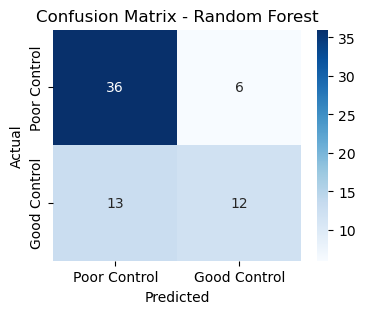

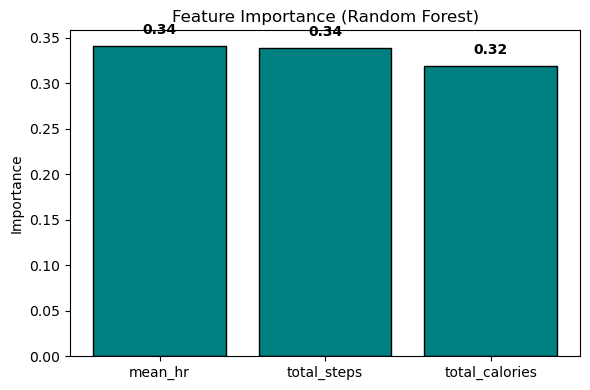

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns

# -------- 1) Daily features --------
df = dfT1DData.copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Mark whether each glucose reading is in range
df["in_range"] = df["glucose"].between(70, 180).astype(int)

# Aggregate per patient per day
daily = (
    df.groupby(["patient_id", "date"], as_index=False)
      .agg(
          total_steps=("steps","sum"),
          mean_hr=("heart_rate","mean"),
          total_calories=("calories_burned","sum"),
          prop_in_range=("in_range","mean")   # fraction of readings in range
      )
)

# -------- 2) Target variable --------
# Define "success" as ≥70% readings in range
daily["target_good_range"] = (daily["prop_in_range"] >= 0.7).astype(int)

# -------- 3) Train/Test split --------
feature_cols = ["total_steps","mean_hr","total_calories"]
X = daily[feature_cols]
y = daily["target_good_range"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# -------- 4) Pipelines --------
preprocess = ColumnTransformer([("num", StandardScaler(), feature_cols)])

logreg = Pipeline(steps=[("prep", preprocess),
                         ("model", LogisticRegression(max_iter=500, class_weight="balanced"))])

rf = Pipeline(steps=[("prep", preprocess),
                     ("model", RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced"))])

# -------- 5) Train & evaluate --------
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n{name} Results:")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("ROC AUC  :", roc_auc_score(y_test, y_prob))

    # Confusion matrix with counts
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Poor Control","Good Control"],
                yticklabels=["Poor Control","Good Control"])
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return model

log_model = evaluate_model("Logistic Regression", logreg, X_train, y_train, X_test, y_test)
rf_model  = evaluate_model("Random Forest", rf, X_train, y_train, X_test, y_test)

# -------- 6) Feature Importance (Random Forest) --------
rf_estimator = rf_model.named_steps["model"]
importances = rf_estimator.feature_importances_
feat_imp = pd.DataFrame({"feature": feature_cols, "importance": importances}).sort_values("importance", ascending=False)

plt.figure(figsize=(6,4))
bars = plt.bar(feat_imp["feature"], feat_imp["importance"], color="teal", edgecolor="black")
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")

# Add data values
for i, v in enumerate(feat_imp["importance"]):
    plt.text(i, v+0.01, f"{v:.2f}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()

#### 4.	Can meal-time carb intake and bolus insulin predict post-meal glucose excursions (e.g., glucose 2 hours after eating)?
- **Goal:** Build models to forecast post-prandial glucose response based on carb and bolus insulin.
- **Clinical Insight:** Helps optimize insulin dosing strategies for meals.



2h Glucose – Linear: RMSE=88.62, MAE=74.98, R²=-0.642
2h Glucose – RandomForest: RMSE=68.73, MAE=52.96, R²=0.012


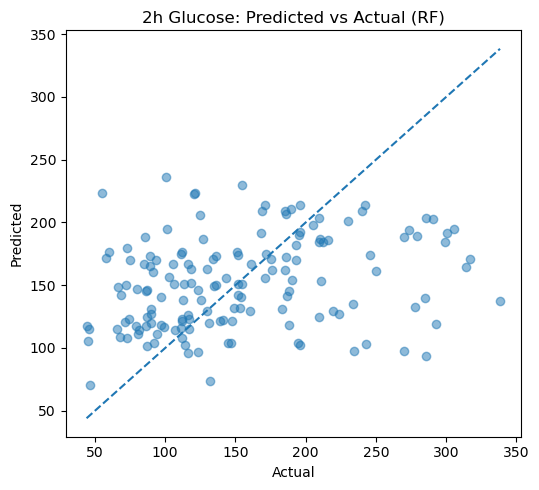


2h Excursion (Δ mg/dL) – Linear: RMSE=88.62, MAE=74.98, R²=-0.950
2h Excursion (Δ mg/dL) – RandomForest: RMSE=71.73, MAE=55.17, R²=-0.278


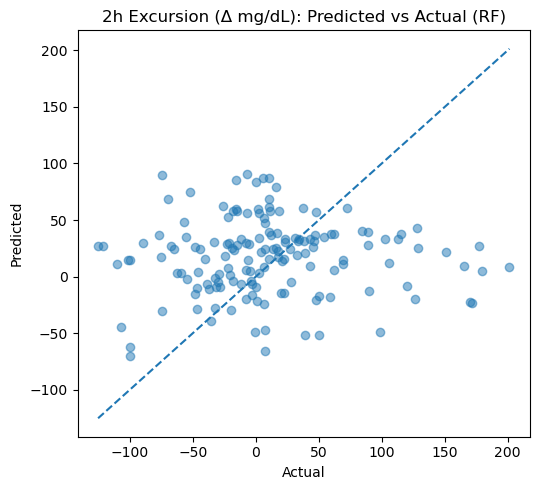


Hyper-2h Classification (RF): Acc=0.605, Prec=0.421, Recall=0.471, F1=0.444, ROC-AUC=0.583


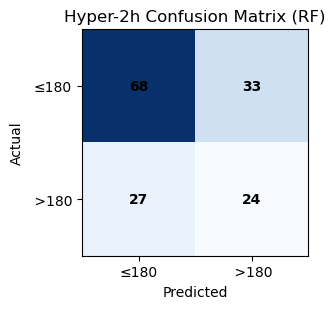

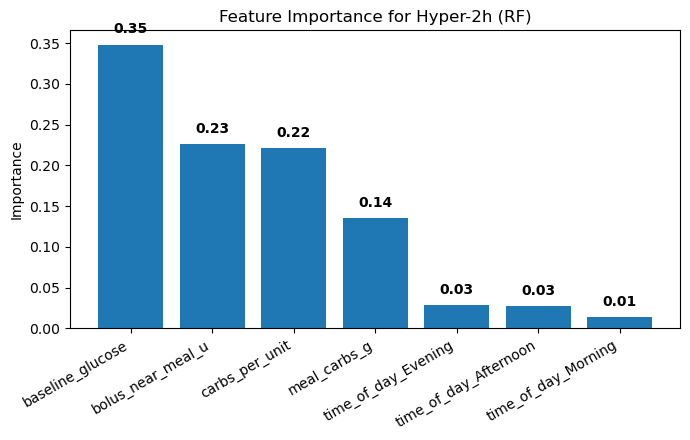

,feature,importance
3,baseline_glucose,0.348308
1,bolus_near_meal_u,0.225850
2,carbs_per_unit,0.220928
0,meal_carbs_g,0.135321
5,time_of_day_Evening,0.028120
4,time_of_day_Afternoon,0.027361
6,time_of_day_Morning,0.014113


In [15]:
# ============================================
# Post-Meal Glucose Excursions @ ~2 hours
# Features: meal carbs, bolus near meal (+ optional time-of-day)
# Targets: glucose_2h, excursion (2h - baseline), hyper_2h (>180)
# Cross-val: GroupKFold by patient_id
# ============================================

import pandas as pd
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression

# ---------- 0) Setup & cleaning ----------
df = dfT1DData.copy()

# Parse datetime
df["date_time"] = pd.to_datetime(df["date_time"], errors="coerce")
df = df.dropna(subset=["date_time", "patient_id"])

# Coerce numeric columns
for col in ["glucose","carb_input_g","bolus_volume_delivered","heart_rate","steps","calories_burned"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Sort for asof merges and windowing
df = df.sort_values(["patient_id","date_time"])

# Create separate frames
glucose_df = df[["patient_id","date_time","glucose"]].dropna().copy()
bolus_df   = df[["patient_id","date_time","bolus_volume_delivered"]].dropna().copy()
carb_df    = df[["patient_id","date_time","carb_input_g"]].dropna().copy()

# ---------- 1) Define meal events ----------
MIN_MEAL_G = 10  # threshold for what counts as a meal (tweakable)
meals = carb_df[carb_df["carb_input_g"] >= MIN_MEAL_G].copy()
meals.rename(columns={"date_time":"meal_time","carb_input_g":"meal_carbs_g"}, inplace=True)

# Optional: add time-of-day bucket
def tod_bucket(dt):
    h = dt.hour
    if 6 <= h < 12:   return "Morning"
    if 12 <= h < 18:  return "Afternoon"
    if 18 <= h < 24:  return "Evening"
    return "Night"

meals["time_of_day"] = meals["meal_time"].apply(tod_bucket)

# ---------- 2) For each meal, compute baseline, bolus near meal, 2h glucose ----------
def nearest_glucose_at(patient_glu, target_time, lo_min=90, hi_min=150):
    lo = target_time + timedelta(minutes=lo_min)
    hi = target_time + timedelta(minutes=hi_min)
    sub = patient_glu[(patient_glu["date_time"] >= lo) & (patient_glu["date_time"] <= hi)]
    if sub.empty:
        return np.nan
    # nearest to 120 min
    sub["abs_diff"] = (sub["date_time"] - (target_time + timedelta(minutes=120))).abs()
    return sub.loc[sub["abs_diff"].idxmin(), "glucose"]

records = []
for pid, sub_meals in meals.groupby("patient_id"):
    gsub = glucose_df[glucose_df["patient_id"]==pid]
    bsub = bolus_df[(bolus_df["patient_id"]==pid) & (bolus_df["bolus_volume_delivered"]>0)]

    for _, row in sub_meals.iterrows():
        t_meal = row["meal_time"]

        # pre-meal baseline: mean glucose in [-30, 0) minutes
        g_pre = gsub[(gsub["date_time"] >= t_meal - timedelta(minutes=30)) &
                     (gsub["date_time"] <  t_meal)]
        baseline = g_pre["glucose"].mean() if not g_pre.empty else np.nan

        # bolus near meal: sum in [-15, +15] minutes
        b_win = bsub[(bsub["date_time"] >= t_meal - timedelta(minutes=15)) &
                     (bsub["date_time"] <= t_meal + timedelta(minutes=15))]
        bolus_near = b_win["bolus_volume_delivered"].sum() if not b_win.empty else 0.0

        # 2h glucose (nearest between 90 and 150 minutes)
        g2h = nearest_glucose_at(gsub.copy(), t_meal, 90, 150)

        records.append({
            "patient_id": pid,
            "meal_time": t_meal,
            "time_of_day": row["time_of_day"],
            "meal_carbs_g": row["meal_carbs_g"],
            "bolus_near_meal_u": bolus_near,
            "baseline_glucose": baseline,
            "glucose_2h": g2h
        })

meal_events = pd.DataFrame(records)

# Drop meals lacking necessary glucose windows
meal_events = meal_events.dropna(subset=["baseline_glucose","glucose_2h"]).reset_index(drop=True)

# Derived targets
meal_events["excursion_2h"] = meal_events["glucose_2h"] - meal_events["baseline_glucose"]
meal_events["hyper_2h"] = (meal_events["glucose_2h"] > 180).astype(int)

# Extra derived feature (handle div-by-zero)
meal_events["carbs_per_unit"] = np.where(meal_events["bolus_near_meal_u"]>0,
                                         meal_events["meal_carbs_g"]/meal_events["bolus_near_meal_u"],
                                         np.nan)

# ---------- 3) Feature matrix ----------
num_feats = ["meal_carbs_g","bolus_near_meal_u","carbs_per_unit","baseline_glucose"]
cat_feats = ["time_of_day"]

# Some models handle NaNs poorly; simple impute for carbs_per_unit
meal_events["carbs_per_unit"] = meal_events["carbs_per_unit"].fillna(meal_events["carbs_per_unit"].median())

X = meal_events[num_feats + cat_feats].copy()
groups = meal_events["patient_id"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_feats),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats)
    ]
)

# ---------- 4) Regression: predict glucose_2h and excursion_2h ----------
for target_col, title in [("glucose_2h","2h Glucose"), ("excursion_2h","2h Excursion (Δ mg/dL)")]:
    y = meal_events[target_col].values

    # Models
    lin = Pipeline([("prep", preprocess), ("model", LinearRegression())])
    rf_reg = Pipeline([("prep", preprocess), ("model", RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1, min_samples_leaf=2))])

    gkf = GroupKFold(n_splits=min(5, len(np.unique(groups))))
    # Out-of-fold predictions
    pred_lin = cross_val_predict(lin, X, y, cv=gkf, groups=groups)
    pred_rf  = cross_val_predict(rf_reg, X, y, cv=gkf, groups=groups)

    def reg_report(name, y_true, y_pred):
        rmse = mean_squared_error(y_true, y_pred, squared=False)
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)
        print(f"{title} – {name}: RMSE={rmse:.2f}, MAE={mae:.2f}, R²={r2:.3f}")

    print("\n" + "="*60)
    reg_report("Linear", y, pred_lin)
    reg_report("RandomForest", y, pred_rf)

    # Plot Predicted vs Actual (RF)
    plt.figure(figsize=(5.5,5))
    plt.scatter(y, pred_rf, alpha=0.5)
    lo, hi = float(min(y.min(), pred_rf.min())), float(max(y.max(), pred_rf.max()))
    plt.plot([lo,hi],[lo,hi],"--")
    plt.title(f"{title}: Predicted vs Actual (RF)")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.tight_layout()
    plt.show()

# ---------- 5) Classification: predict Hyper-2h (>180) ----------
y_clf = meal_events["hyper_2h"].values

log_clf = Pipeline([("prep", preprocess), ("model", LogisticRegression(max_iter=500, class_weight="balanced"))])
rf_clf  = Pipeline([("prep", preprocess), ("model", RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1, min_samples_leaf=2, class_weight="balanced"))])

gkf = GroupKFold(n_splits=min(5, len(np.unique(groups))))
pred_prob_rf = cross_val_predict(rf_clf, X, y_clf, cv=gkf, groups=groups, method="predict_proba")[:,1]
pred_lab_rf  = (pred_prob_rf >= 0.5).astype(int)

# Metrics
acc = accuracy_score(y_clf, pred_lab_rf)
prec = precision_score(y_clf, pred_lab_rf, zero_division=0)
rec = recall_score(y_clf, pred_lab_rf, zero_division=0)
f1  = f1_score(y_clf, pred_lab_rf, zero_division=0)
auc = roc_auc_score(y_clf, pred_prob_rf) if len(np.unique(y_clf))>1 else np.nan
print("\n" + "="*60)
print(f"Hyper-2h Classification (RF): Acc={acc:.3f}, Prec={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}, ROC-AUC={auc:.3f}")

# Confusion matrix with counts
cm = confusion_matrix(y_clf, pred_lab_rf, labels=[0,1])
fig, ax = plt.subplots(figsize=(4,3.2))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Hyper-2h Confusion Matrix (RF)")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["≤180"," >180"]); ax.set_yticklabels(["≤180"," >180"])
# Put counts on the cells
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontweight="bold")
plt.tight_layout()
plt.show()

# Feature importance (RF) with value labels
rf_clf.fit(X, y_clf)  # fit once on all data to extract importances
ohe = rf_clf.named_steps["prep"].named_transformers_["cat"]
cat_names = list(ohe.get_feature_names_out(cat_feats)) if cat_feats else []
feat_names = num_feats + cat_names
importances = rf_clf.named_steps["model"].feature_importances_

imp = pd.DataFrame({"feature": feat_names, "importance": importances}).sort_values("importance", ascending=False)

plt.figure(figsize=(7,4.5))
bars = plt.bar(imp["feature"], imp["importance"])
plt.xticks(rotation=30, ha="right")
plt.title("Feature Importance for Hyper-2h (RF)")
plt.ylabel("Importance")
# Add value labels on bars
for i, v in enumerate(imp["importance"].values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.show()

imp.head(10)